# Mountain glaciers: 
## Thompson Quelccaya summit dome ice core:

In [1]:
# load libraries, read time series data:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import griddata
from numpy import linalg
from scipy import stats
import cartopy.crs as ccrs
from scipy.stats import linregress
from scipy.signal import savgol_filter # for smoothing time series
from scipy.interpolate import griddata
from scipy import optimize

# uncomment for interactive plots, following https://stackoverflow.com/questions/50149562/jupyterlab-interactive-plot
#%matplotlib widget

# Import the csv datasets:
# -----------------------
print("---> long core with annual data:")
# File with Quelccaya summit dome ice core with data from about 220 to 2010:
filename='../../../Data-for-teaching-staff/Mountain-glaciers/Ice-cores/quelccaya2013.txt'
dataset = pd.read_csv(filename, encoding = "latin",delim_whitespace=False,sep='\t',lineterminator='\n',na_values='NaN' \
          ,comment='#',skipinitialspace=False,skip_blank_lines=False,header=0,index_col=False)
data = np.asarray(dataset.iloc[:, :].values)
header = dataset.iloc[:, :].columns
years=data[:,0]
delta18O=data[:,1]
acc_rate=data[:,2]
print("header:",header)
print("years:",years)
print("delta18O:",delta18O)
print("accumulation rate:",acc_rate)

print("---> sub-annual resolution core from 1976:")
# File with Quelccaya ice core with seasonal resolution, from 1976:
filename='../../../Data-for-teaching-staff/Mountain-glaciers/Ice-cores/quelccaya2017qic1976d18o.txt'
dataset1976 = pd.read_csv(filename, encoding = "latin",delim_whitespace=False,sep='\t',lineterminator='\n',na_values='NaN' \
          ,comment='#',skipinitialspace=False,skip_blank_lines=False,header=0,index_col=False)
data1976 = np.asarray(dataset1976.iloc[:, :].values)
header1976 = dataset1976.iloc[:, :].columns
depth1976=data1976[:,0]
delta18O1976=data1976[:,1]
print("header 1976:",header1976)
print("depth 1976:",depth1976)
print("delta18O 1976:",delta18O1976)

print("---> sub-annual resolution core from 2016:")
# File with Quelccaya ice core with seasonal resolution, from 1976:
filename='../../../Data-for-teaching-staff/Mountain-glaciers/Ice-cores/quelccaya2017qic2016d18o.txt'
dataset2016 = pd.read_csv(filename, encoding = "latin",delim_whitespace=False,sep='\t',lineterminator='\n',na_values='NaN' \
          ,comment='#',skipinitialspace=False,skip_blank_lines=False,header=0,index_col=False)
data2016 = np.asarray(dataset2016.iloc[:, :].values)
header2016 = dataset2016.iloc[:, :].columns
depth2016=data2016[:,0]
delta18O2016=data2016[:,1]
print("header 2016:",header2016)
print("depth 2016:",depth2016)
print("delta18O 2016:",delta18O2016)


---> long core with annual data:
header: Index(['age_AD', 'd18OiceSMOW', 'iceacc_m  dust', 'f_ppb', 'cl_ppb', 'so4_ppb',
       'no3_ppb', 'na_ppb', 'nh4_ppb', 'k_ppb', 'mg_ppb', 'ca_ppb'],
      dtype='object')
years: [2009. 2008. 2007. ...  228.  227.  226.]
delta18O: [-18.59 -16.32 -16.23 ... -17.33 -17.48 -18.12]
accumulation rate: [1.22 1.29 1.46 ...  nan  nan  nan]
---> sub-annual resolution core from 1976:
header 1976: Index(['depth_m', 'd18O\r'], dtype='object')
depth 1976: [ 0.05  0.1   0.15  0.2   0.25  0.3   0.35  0.4   0.45  0.5   0.55  0.6
  0.65  0.7   0.75  0.8   0.85  0.9   0.95  1.    1.05  1.1   1.15  1.2
  1.25  1.3   1.35  1.4   1.45  1.5   1.55  1.6   1.65  1.7   1.75  1.8
  1.85  1.9   1.95  2.    2.05  2.1   2.15  2.2   2.25  2.3   2.35  2.4
  2.45  2.5   2.55  2.6   2.65  2.7   2.75  2.8   2.85  2.9   2.95  3.
  3.05  3.1   3.15  3.2   3.25  3.3   3.35  3.4   3.45  3.5   3.55  3.61
  3.71  3.83  3.94  4.05  4.14  4.24  4.34  4.44  4.54  4.64  4.71  4.78
  4.85  

/var/folders/0v/wvw14yq11b34jdy4j2h8fsx80000gn/T/ipykernel_12240/3812477685.py:22: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataset = pd.read_csv(filename, encoding = "latin",delim_whitespace=False,sep='\t',lineterminator='\n',na_values='NaN' \
/var/folders/0v/wvw14yq11b34jdy4j2h8fsx80000gn/T/ipykernel_12240/3812477685.py:22: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  dataset = pd.read_csv(filename, encoding = "latin",delim_whitespace=False,sep='\t',lineterminator='\n',na_values='NaN' \
/var/folders/0v/wvw14yq11b34jdy4j2h8fsx80000gn/T/ipykernel_12240/3812477685.py:37: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataset1976 = pd.read_csv(filename, encoding = "latin",delim_whitespace=False,sep='\t',linetermi

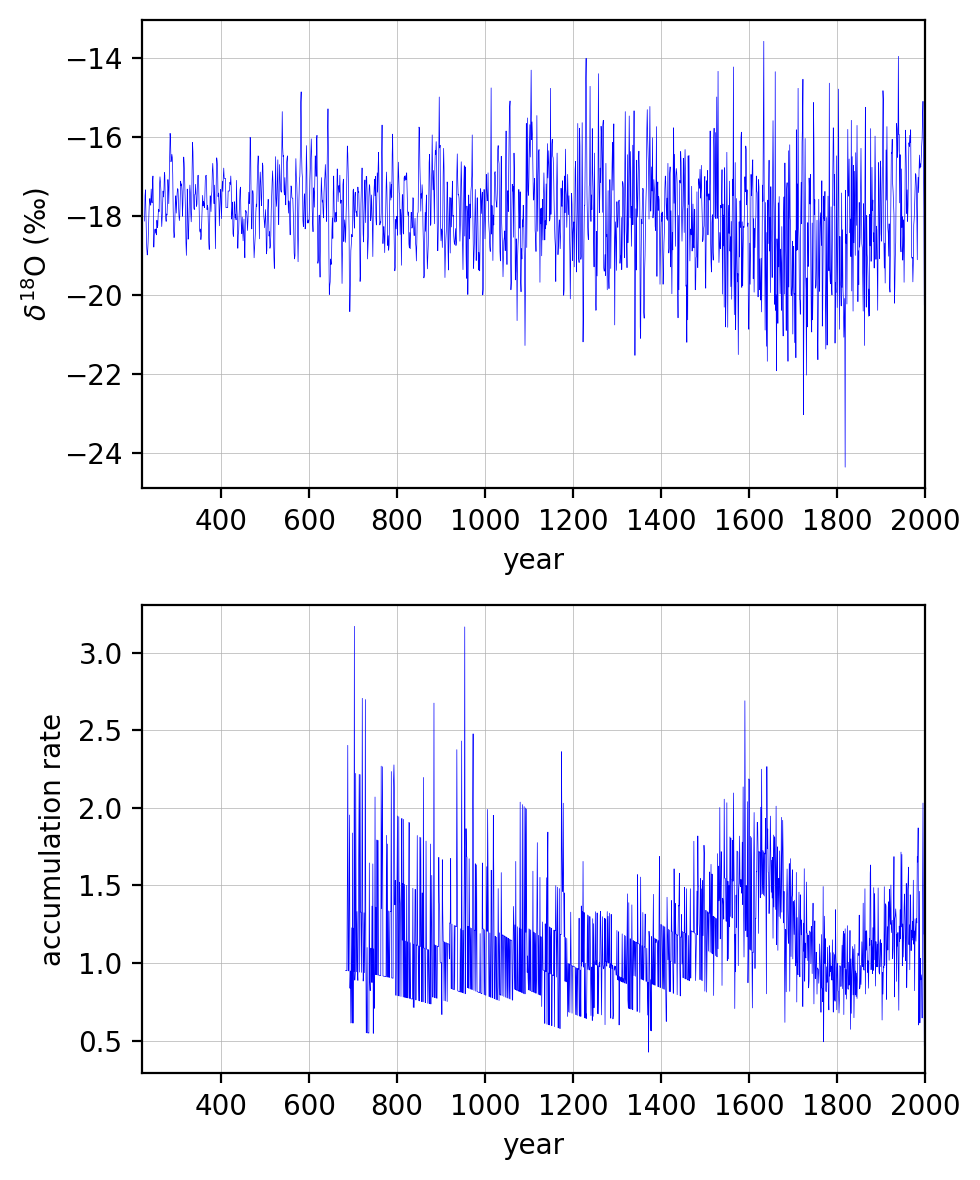

In [2]:
plt.figure(figsize=(5,6),dpi=200)

plt.subplot(2,1,1)
plt.plot(years,delta18O,lw=0.25,color='b')
plt.xlabel('year')
plt.ylabel('$\delta^{18}$O (‰)')
plt.xlim(220,2000)
plt.grid(lw=0.25)

plt.subplot(2,1,2)
plt.plot(years,acc_rate,lw=0.25,color='b')
plt.xlabel('year')
plt.ylabel('accumulation rate')
plt.xlim(220,2000)
plt.grid(lw=0.25)
plt.tight_layout()

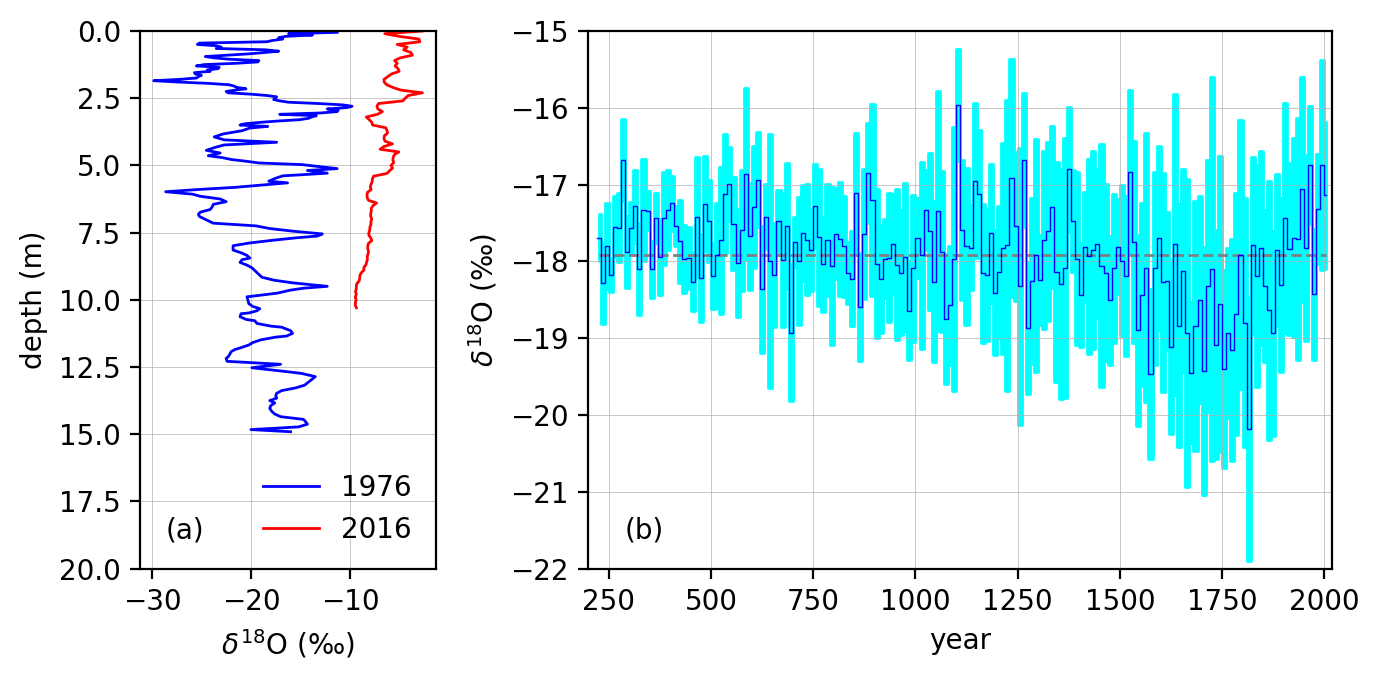

In [3]:
# save data for student workshop:
Quelccaya_years=years
Quelccaya_delta18O=delta18O
Quelccaya_delta18O1976=delta18O1976
Quelccaya_depth1976=depth1976
Quelccaya_delta18O2016=delta18O2016
Quelccaya_depth2016=depth2016

np.save("Output/to-pickle/Quelccaya_years.npy",Quelccaya_years)
np.save("Output/to-pickle/Quelccaya_delta18O.npy",Quelccaya_delta18O)
np.save("Output/to-pickle/Quelccaya_delta18O1976.npy",Quelccaya_delta18O1976)
np.save("Output/to-pickle/Quelccaya_depth1976.npy",Quelccaya_depth1976)
np.save("Output/to-pickle/Quelccaya_delta18O2016.npy",Quelccaya_delta18O2016)
np.save("Output/to-pickle/Quelccaya_depth2016.npy",Quelccaya_depth2016)

# calculate bin-averaged glacier length:
bin_edges=np.arange(200,2020,10)
bin_means, bin_edges, binnumber \
      = stats.binned_statistic(Quelccaya_years,Quelccaya_delta18O, statistic='mean',bins=bin_edges)
# bin-averaged std:
bin_std, bin_edges, binnumber \
      = stats.binned_statistic(Quelccaya_years,Quelccaya_delta18O, statistic='std',bins=bin_edges)
# number of data points per bin:
bin_count, bin_edges, binnumber \
      = stats.binned_statistic(Quelccaya_years,Quelccaya_delta18O, statistic='count',bins=bin_edges)
years_axis=(bin_edges[0:-1]+bin_edges[1:])*0.5

# mean of decadal averages:
mean=np.nanmean(bin_means)

# plot:
props = dict(boxstyle='round', edgecolor="white", facecolor='white', alpha=1.0)
fig=plt.figure(figsize=(7,3.5),dpi=200)

plt.subplot2grid((1,3), (0, 0), colspan=1)
plt.plot(Quelccaya_delta18O1976,Quelccaya_depth1976,lw=1,color='b',label="1976")
plt.plot(Quelccaya_delta18O2016+10,Quelccaya_depth2016,lw=1,color='r',label="2016")
plt.ylabel('depth (m)')
plt.xlabel('$\delta^{18}$O (‰)')
#plt.xlim(220,2000)
plt.ylim(0,20)
plt.gca().invert_yaxis()
plt.grid(lw=0.25)
plt.legend(loc="lower right",frameon=False)
ax1=plt.gca()
ax1.text(0.15, 0.07, "(a)",transform=ax1.transAxes, fontsize=10,
        horizontalalignment='center',verticalalignment='center', bbox=props)


plt.subplot2grid((1,3), (0, 1), colspan=2)
plt.fill_between(years_axis,bin_means-bin_std,bin_means+bin_std,step='mid',color="cyan")
plt.plot(years_axis,0*bin_means+mean,lw=1,ls="--",color="grey")
plt.plot(years_axis,bin_means,drawstyle='steps-mid',lw=0.5,color="b")
plt.xlabel("year")
plt.ylabel('$\delta^{18}$O (‰)')
plt.xlim(200,2020)
plt.ylim(-22,-15)
plt.grid(lw=0.25)
ax1=plt.gca()
ax1.text(0.075, 0.07, "(b)",transform=ax1.transAxes, fontsize=10,
        horizontalalignment='center',verticalalignment='center', bbox=props)

plt.tight_layout()